## 05 - Model testing and comparing

### 🎯 Notebook's objective

In this notebook, the aim is to test and compare the different models and strategies used. Other models developed in similar studies will also be tested and compared to the models developed in this project. The models were briefly tested in the previous notebook, the tests will now be more complete and comparative.

### 🏛️ Notebook's Structure

The notebook's structure is as follows:

- **Imports**: All necessary libraries and functions will be imported.
- **Model, Scaler, and Data loading**: Each necessary elements will be loaded and imported in this notebook.
- **Predictions**: The models will be used on the test sets to create predicted sets.
- **Evaluation**: Evaluation functions will be defined and used on the predicted results. These will then be visualised and compared with results from other studies.
- **Error analysis**: An error analysis will be performed to try and identify error sources and potential improvement areas.
- **Conclusion**: The notebook will end with a brief conclusion to summarize and discuss the notebook's results.

### 📚 Library and functions imports

A few libraries and functions will be necessary throughout the notebook. 

In [1]:
# Import necessary libraries
import joblib
import torch
import numpy as np
import sys
import matplotlib.pyplot as plt
import shap

# Import necessary functions
from sklearn.preprocessing import StandardScaler

# Import functions from model_utils.py
sys.path.append('../models')  
from model_utils import test_model, NeuralNetwork, ESOLDataset, NeuralNetworkDataModule

c:\Users\corre\Documents\GitHub_gen\GitHub\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 💾 Model, Scaler, and Data loading

The first task is to load the models, scaler, and data into this notebook.

In [2]:
# Load the trained regression models and scalers using joblib 
rf_model = joblib.load("../models/RandomForest.pth")
xgb_model = joblib.load("../models/XGBoost.pth")
x_scaler = joblib.load("../models/feature_scaler.pth")

# Import the data
x_train = np.load("../data/final/Split new/X_train.npy")
y_train = np.load("../data/final/Split new/y_train.npy")
x_test  = np.load("../data/final/Split new/X_test.npy")
y_test  = np.load("../data/final/Split new/y_test.npy")

# Convert percentage yield values from 0-100 into a 0-1 range (delete later if this is done in a different notebook)
y_train = y_train / 100.0
y_test = y_test / 100.0

# Load the trained neural network model using PyTorch's state_dict
input_size = x_train.shape[1]
hidden_size = 128
nn_model = NeuralNetwork.load_from_checkpoint("../models/lightning_nn.ckpt", input_sz=input_size, hidden_sz=hidden_size, lr=1e-3)
nn_model.eval()

NeuralNetwork(
  (net): Sequential(
    (0): Linear(in_features=473, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)

### 🔮 Predictions

Let's now use the models to obtain their respective predicted results.

In [3]:
# Use the regression models on the test set
y_pred_rf = rf_model.predict(x_test)
y_pred_xgb = xgb_model.predict(x_test)

# Use the neural network model on the test set
y_pred_nn = nn_model(torch.tensor(x_test, dtype=torch.float32)).squeeze().detach().numpy()

### 📝 Evaluation

Now the predicted results must be compared to the real values to evaluate the performance of different models. First a few evaluation functions must be defined. The testing functions defined in the previous notebook can be reused to simplify this task.

#### **Evaluation functions definition**

##### **Parity plot function**

In [4]:
# Parity plot function for ml models
def parity_plot(y_true, y_pred, model_name, title):
    # Use the test_model function to calculate metrics
    metrics = test_model(model_name, y_true, y_pred)

    # Create a parity plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([0, 1], [0, 1], 'r--')  # Line for perfect predictions
    plt.xlabel('Actual Yield')
    plt.ylabel('Predicted Yield')
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid()

    # Display metrics in the corner of the plot
    metrics_text = (
        f"RMSE: {metrics['RMSE']:.4f}\n"
        f"MAE: {metrics['MAE']:.4f}\n"
        f"R2: {metrics['R2 Score']:.4f}\n"
        f"Explained Var: {metrics['Explained Variance Score']:.4f}"
    )
    plt.text(
        0.05,
        0.95,
        metrics_text,
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='black', boxstyle='round,pad=0.5')
    )

    plt.show()


This function creates a parity scatter plot comparing actual versus predicted values. Useful to visualize the precision of a model and to have a quick idea of which actual yields are difficult to predict.

##### **Error histogram function**

In [5]:
# Error distribution visualization - Histogram
def plot_error_histogram(y_true, y_pred, model_name, title=None, bins=30, absolute=False):
    """
    Plot histogram of prediction errors.
    
    Parameters:
    y_true: True labels
    y_pred: Predicted labels
    model_name: Name of the model for labeling
    title: Optional title for the plot
    bins: Number of histogram bins
    absolute: If True, plot absolute errors; if False, plot signed errors (residuals)
    """
    errors = y_pred - y_true
    if absolute:
        errors = np.abs(errors)
    
    plt.figure(figsize=(10, 5))
    plt.hist(errors, bins=bins, alpha=0.7, edgecolor='black', color='steelblue')
    plt.xlabel('Error (Absolute)' if absolute else 'Error (Residuals)')
    plt.ylabel('Frequency')
    plt.title(title or f'{model_name} - Error Distribution')
    plt.axvline(np.mean(errors), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(errors):.4f}')
    plt.axvline(np.median(errors), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(errors):.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

This function visualizes the error distribution as a histogram and highlights mean/median values. Can be used to have a quick estimate of the model precision.

##### **Error boxplot function**

In [6]:
# Error distribution visualization - Boxplot with statistics
def plot_error_boxplot(y_true, y_pred, model_name, title=None, absolute=False):
    """
    Plot boxplot of prediction errors with statistical summary.
    
    Parameters:
    y_true: True labels
    y_pred: Predicted labels
    model_name: Name of the model for labeling
    title: Optional title for the plot
    absolute: If True, plot absolute errors; if False, plot signed errors (residuals)
    """
    errors = y_pred - y_true
    if absolute:
        errors = np.abs(errors)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    bp = ax.boxplot(errors, vert=True, patch_artist=True, widths=0.5)
    
    # Customize boxplot colors
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    for whisker in bp['whiskers']:
        whisker.set(color='black', linewidth=1.5)
    for cap in bp['caps']:
        cap.set(color='black', linewidth=1.5)
    for median in bp['medians']:
        median.set(color='red', linewidth=2)
    
    ax.set_ylabel('Error (Absolute)' if absolute else 'Error (Residuals)')
    ax.set_title(title or f'{model_name} - Error Distribution')
    ax.set_xticklabels([model_name])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add statistics as text
    stats_text = (
        f"Mean: {np.mean(errors):.4f}\n"
        f"Median: {np.median(errors):.4f}\n"
        f"Std Dev: {np.std(errors):.4f}\n"
        f"Min: {np.min(errors):.4f}\n"
        f"Max: {np.max(errors):.4f}"
    )
    ax.text(1.15, np.max(errors) * 0.8, stats_text, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

This function shows the error distribution using a boxplot, with summary statistics displayed. Same use as the previous function but with a different display.

##### **Metrics comparison function**

In [7]:
# Metrics comparison bar plot function
def plot_metrics_comparison(metrics_list, title_prefix="Model Comparison"):
    """
    Plot comparison of all metrics across multiple models using bar plots.
    
    Parameters:
    metrics_list: List of dictionaries returned by test_model() for different models
    title_prefix: Prefix for the main plot title
    """
    # Extract model names and metrics
    model_names = [m['Model'] for m in metrics_list]
    rmse_values = [m['RMSE'] for m in metrics_list]
    mae_values = [m['MAE'] for m in metrics_list]
    r2_values = [m['R2 Score'] for m in metrics_list]
    var_values = [m['Explained Variance Score'] for m in metrics_list]
    
    # Create subplots for each metric
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title_prefix, fontsize=16, fontweight='bold')
    
    # Plot 1: RMSE (lower is better)
    axes[0, 0].bar(model_names, rmse_values, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0, 0].set_ylabel('RMSE', fontsize=11, fontweight='bold')
    axes[0, 0].set_title('Root Mean Squared Error')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(rmse_values):
        axes[0, 0].text(i, v + max(rmse_values)*0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot 2: MAE (lower is better)
    axes[0, 1].bar(model_names, mae_values, color='darkorange', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0, 1].set_ylabel('MAE', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Mean Absolute Error')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(mae_values):
        axes[0, 1].text(i, v + max(mae_values)*0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot 3: R2 Score (higher is better)
    axes[1, 0].bar(model_names, r2_values, color='green', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[1, 0].set_ylabel('R² Score', fontsize=11, fontweight='bold')
    axes[1, 0].set_title('R² Score')
    axes[1, 0].set_ylim([0, 1.05])
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(r2_values):
        axes[1, 0].text(i, v + 0.03, f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot 4: Explained Variance Score (higher is better)
    axes[1, 1].bar(model_names, var_values, color='purple', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[1, 1].set_ylabel('Explained Variance Score', fontsize=11, fontweight='bold')
    axes[1, 1].set_title('Explained Variance Score')
    axes[1, 1].set_ylim([0, 1.05])
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(var_values):
        axes[1, 1].text(i, v + 0.03, f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

This function compares model metrics across multiple models using bar plots. More practical to visualize and compare model statistics.

#### **ML Models Evaluation**

Now the functions can be used on the predicted results.

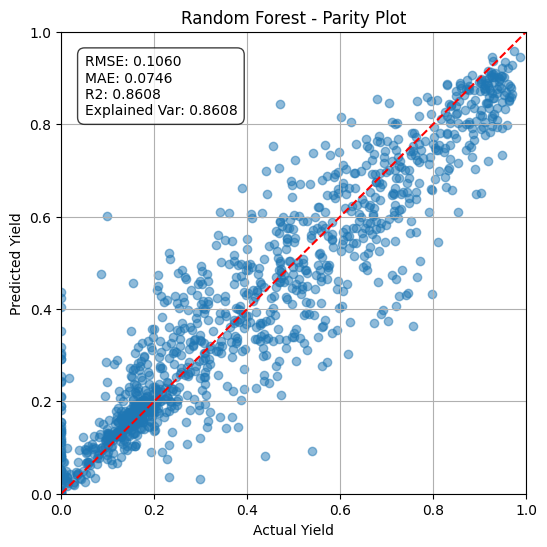

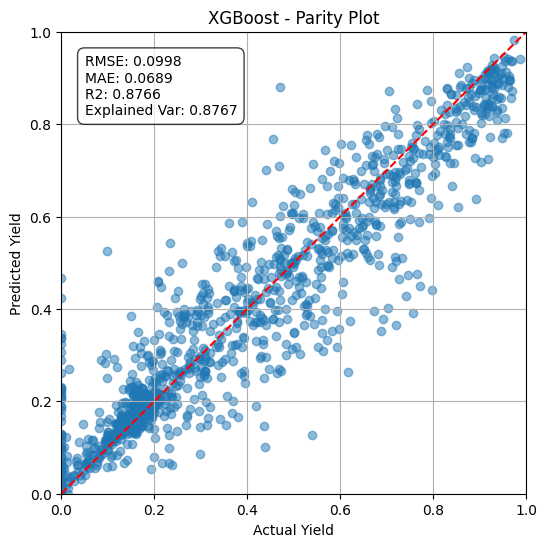

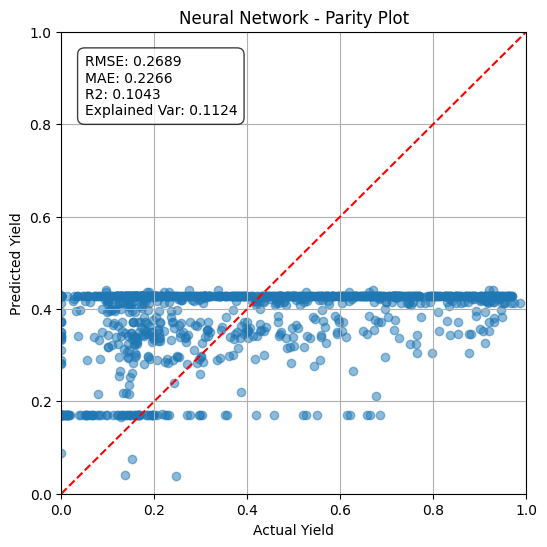

In [8]:
# Parity plots for all models
parity_plot(y_test, y_pred_rf, "Random Forest", "Random Forest - Parity Plot")
parity_plot(y_test, y_pred_xgb, "XGBoost", "XGBoost - Parity Plot")
parity_plot(y_test, y_pred_nn, "Neural Network", "Neural Network - Parity Plot")

(future comments)

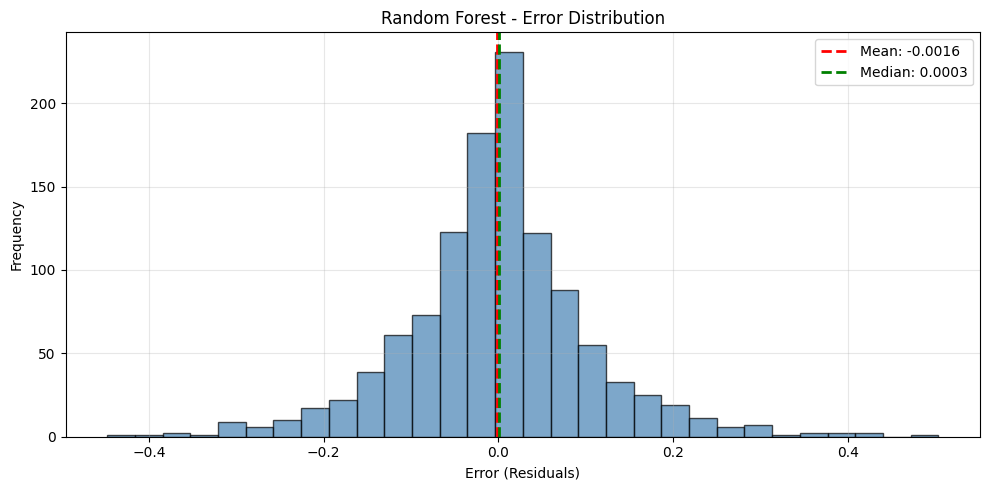

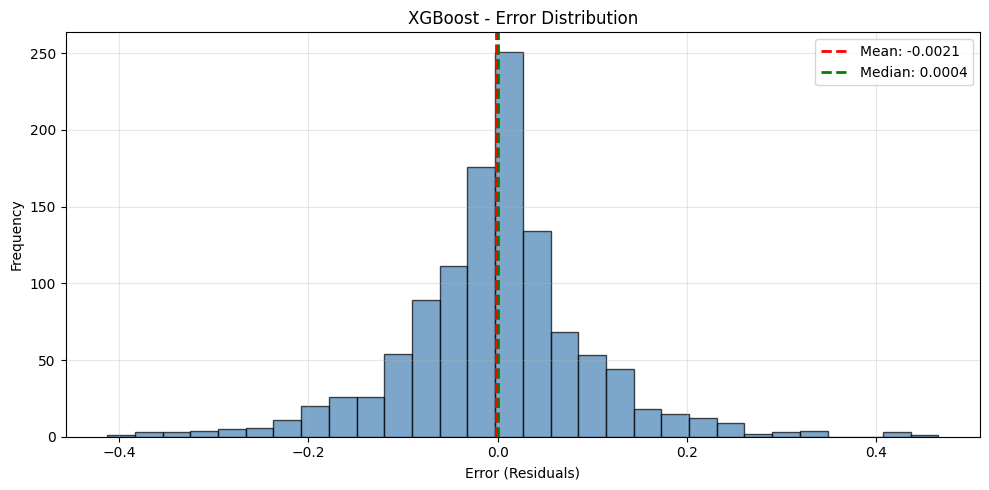

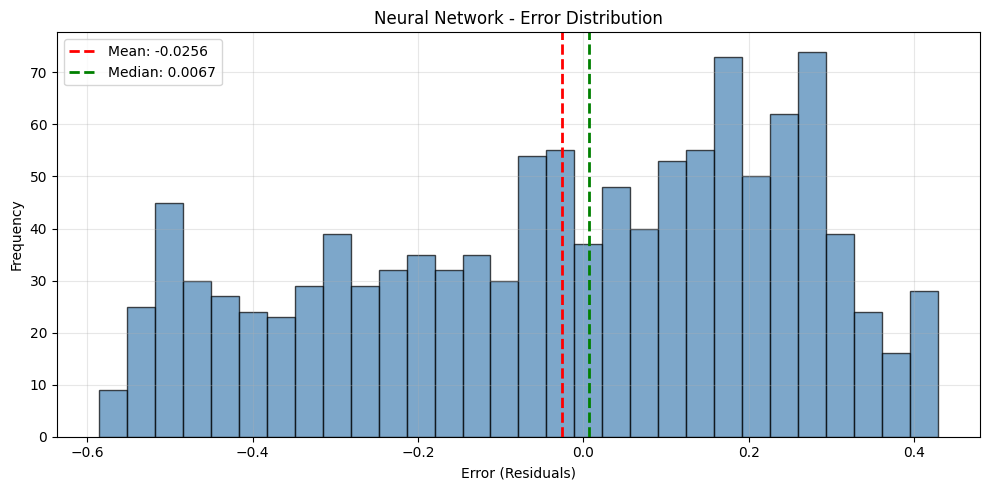

In [9]:
# Error distribution visualizations for all models - Histograms
plot_error_histogram(y_test, y_pred_rf, "Random Forest", "Random Forest - Error Distribution")
plot_error_histogram(y_test, y_pred_xgb, "XGBoost", "XGBoost - Error Distribution")
plot_error_histogram(y_test, y_pred_nn, "Neural Network", "Neural Network - Error Distribution")

(future comments)

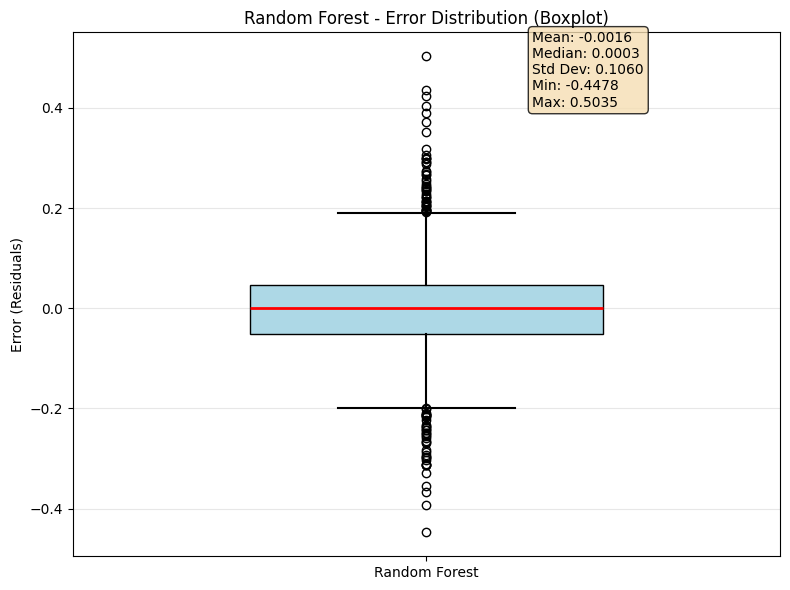

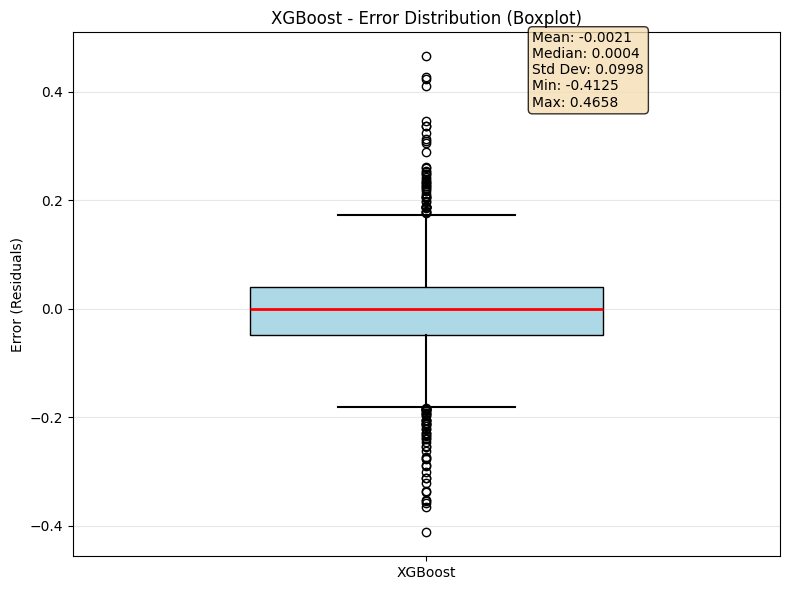

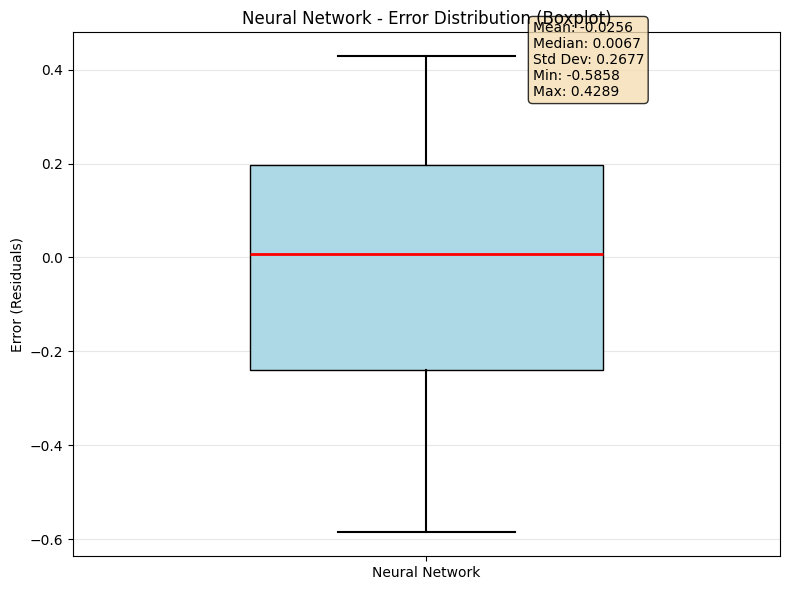

In [10]:
# Error distribution visualizations for all models - Boxplots with statistics
plot_error_boxplot(y_test, y_pred_rf, "Random Forest", "Random Forest - Error Distribution (Boxplot)")
plot_error_boxplot(y_test, y_pred_xgb, "XGBoost", "XGBoost - Error Distribution (Boxplot)")
plot_error_boxplot(y_test, y_pred_nn, "Neural Network", "Neural Network - Error Distribution (Boxplot)")

(future comments)

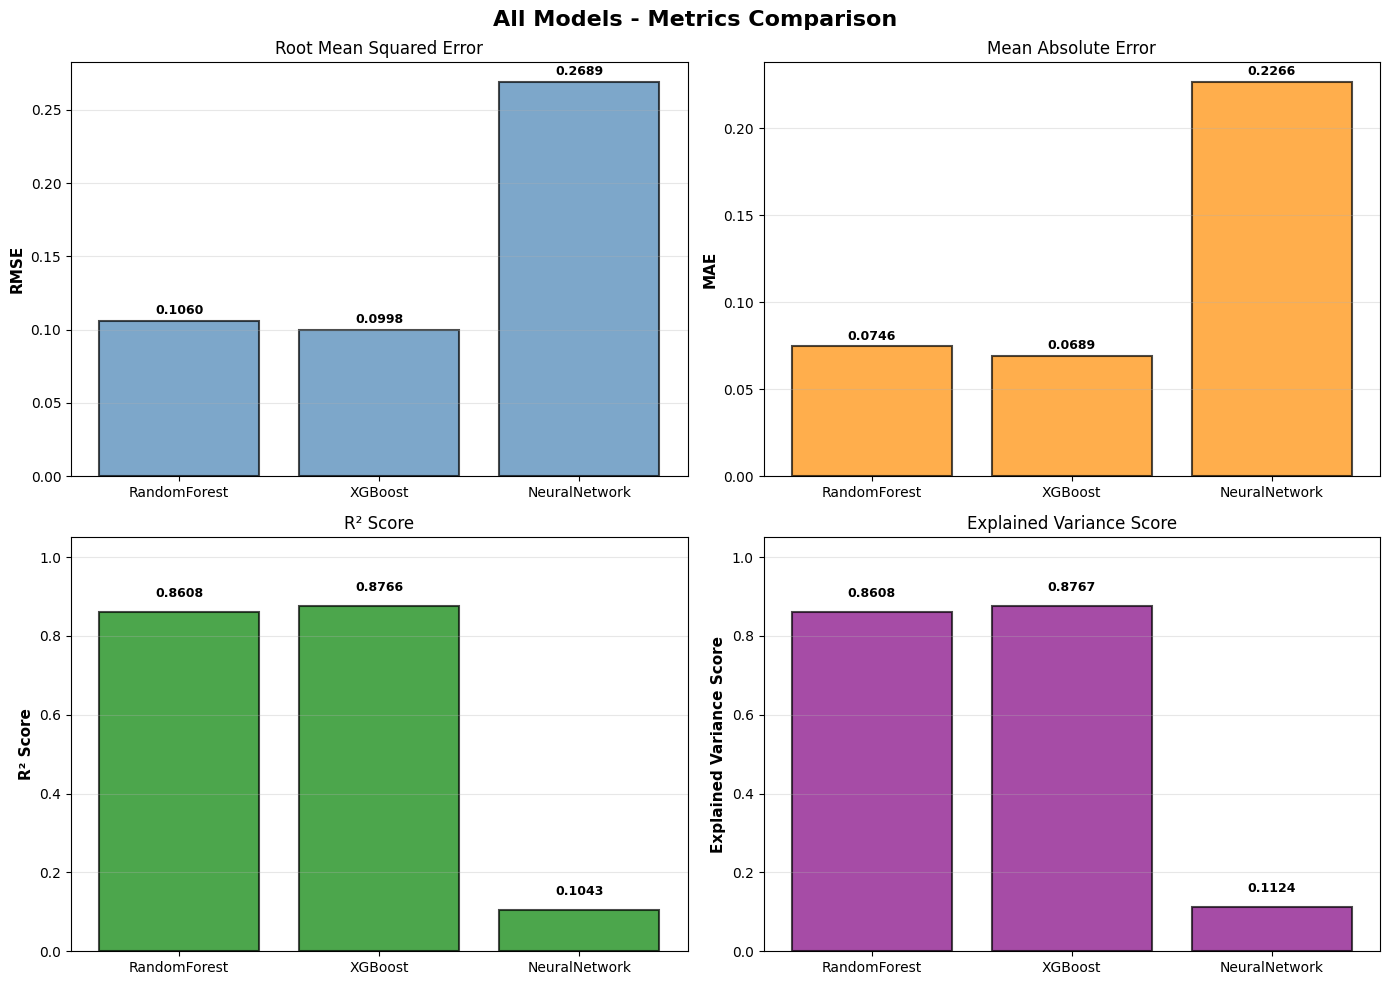

In [11]:
# Metrics comparison bar plot
# Collect metrics from all models
metrics_rf = test_model("RandomForest", y_test, y_pred_rf)
metrics_xgb = test_model("XGBoost", y_test, y_pred_xgb)
metrics_nn = test_model("NeuralNetwork", y_test, y_pred_nn)

# Create comparison plot
plot_metrics_comparison([metrics_rf, metrics_xgb, metrics_nn], "All Models - Metrics Comparison")

(future comments)

#### **Models from other studies**

(section to complete later)

### 🔍 Error analysis

In this section, the error causes are explored and possible improvement areas are discussed. The previous section analysed the performance of the models, which could give some hints about possible improvements. This section focuses on this aspect more in detail. The models cannot be perfect, but some errors and innacurracies can potentially be avoided. 

#### **Visualisation functions definition**

Some functions can be defined to try and identify error causes through visualisation.

##### **Error by actual value**

In [12]:
def plot_error_by_actual_value(y_true, y_pred, model_name, n_bins=20, show_sample_count=False):
    """Visualize which actual target values produce larger model errors."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    errors = np.abs(y_pred - y_true)

    # Define bins across the range of actual values
    bin_edges = np.linspace(np.min(y_true), np.max(y_true), n_bins + 1)
    bin_centers = []
    mean_abs_errors = []
    std_abs_errors = []
    counts = []

    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (y_true >= bin_edges[i]) & (y_true < bin_edges[i + 1])
        else:
            mask = (y_true >= bin_edges[i]) & (y_true <= bin_edges[i + 1])

        if not np.any(mask):
            continue

        bin_centers.append((bin_edges[i] + bin_edges[i + 1]) / 2)
        mean_abs_errors.append(np.mean(errors[mask]))
        std_abs_errors.append(np.std(errors[mask]))
        counts.append(np.sum(mask))

    plt.figure(figsize=(12, 6))
    plt.bar(bin_centers, mean_abs_errors, width=(bin_edges[1] - bin_edges[0]) * 0.9,
            color='steelblue', alpha=0.8, edgecolor='black', label='Mean Absolute Error')
    plt.errorbar(bin_centers, mean_abs_errors, yerr=std_abs_errors,
                 fmt='o', color='black', capsize=4, label='Std Dev')
    plt.xlabel('Actual Yield')
    plt.ylabel('Mean Absolute Error')
    plt.title(f'{model_name} - Error Magnitude by Actual Result Value')
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    if show_sample_count:
        plt.figure(figsize=(12, 4))
        plt.bar(bin_centers, counts, width=(bin_edges[1] - bin_edges[0]) * 0.9,
                color='darkorange', alpha=0.7, edgecolor='black')
        plt.xlabel('Actual Yield')
        plt.ylabel('Number of Samples')
        plt.title(f'{model_name} - Sample Count per Actual Value Bin')
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()


This function plots the mean absolute error and error spread vs actual yield bin. It also plots the sample counts per actual value bins if show_sample_count is True. This is useful to try and identify the actual value for which the model struggles the most and does most errors. A correlation could be observed with the distribution of actual values in the testing set.

##### **Error by predicted value**

In [13]:
def plot_error_by_predicted_value(y_true, y_pred, model_name, n_bins=20, show_sample_count=False):
    """Visualize absolute prediction errors binned by predicted values."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    errors = np.abs(y_pred - y_true)

    # Define bins across the range of predicted values
    bin_edges = np.linspace(np.min(y_pred), np.max(y_pred), n_bins + 1)
    bin_centers = []
    mean_abs_errors = []
    std_abs_errors = []
    counts = []

    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (y_pred >= bin_edges[i]) & (y_pred < bin_edges[i + 1])
        else:
            mask = (y_pred >= bin_edges[i]) & (y_pred <= bin_edges[i + 1])

        if not np.any(mask):
            continue

        bin_centers.append((bin_edges[i] + bin_edges[i + 1]) / 2)
        mean_abs_errors.append(np.mean(errors[mask]))
        std_abs_errors.append(np.std(errors[mask]))
        counts.append(np.sum(mask))

    plt.figure(figsize=(12, 6))
    plt.bar(bin_centers, mean_abs_errors, width=(bin_edges[1] - bin_edges[0]) * 0.9,
            color='steelblue', alpha=0.8, edgecolor='black', label='Mean Absolute Error')
    plt.errorbar(bin_centers, mean_abs_errors, yerr=std_abs_errors,
                 fmt='o', color='black', capsize=4, label='Std Dev')
    plt.xlabel('Predicted Yield')
    plt.ylabel('Mean Absolute Error')
    plt.title(f'{model_name} - Error Magnitude by Predicted Value')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    if show_sample_count:
        plt.figure(figsize=(12, 4))
        plt.bar(bin_centers, counts, width=(bin_edges[1] - bin_edges[0]) * 0.9,
                color='darkorange', alpha=0.7, edgecolor='black')
        plt.xlabel('Predicted Yield')
        plt.ylabel('Number of Samples')
        plt.title(f'{model_name} - Sample Count per Predicted Value Bin')
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()


This function plots the mean absolute error and actual spread vs predicted yield bin. It also shows the distribution of predicted yields if show_sample_count is set to True. This plot can be used to see which predicted values tend to be wrong. For example if the model has a high chance of predicting a yield of 0.5 no matter the input, it will probably have a high MAE for this predicted value and have a high number of predictions close to 0.5.

##### **SHAP explainability analysis**

In [14]:
def plot_shap_feature_importance(model, X_data, model_name, num_samples=100):
    """
    Generate and visualize SHAP values to identify which features drive predictions and errors.
    Automatically detects model type (tree-based or neural network) and uses appropriate explainer.
    
    Parameters:
    model: Trained model (RandomForest, XGBoost, or PyTorch Neural Network)
    X_data: Feature matrix for analysis
    model_name: Name of the model for labeling
    num_samples: Number of samples to use for SHAP explainer (for performance). Use None for all.
    """
    # Use subset for faster computation if num_samples specified
    if num_samples and num_samples < len(X_data):
        indices = np.random.choice(len(X_data), size=num_samples, replace=False)
        X_sample = X_data[indices]
    else:
        X_sample = X_data
    
    # Detect model type
    model_type = type(model).__name__
    is_tree_based = 'RandomForest' in model_type or 'XGB' in model_type
    
    if is_tree_based:
        # Use TreeExplainer for tree-based models
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
        
        # If multiple outputs, take the first one (for regression)
        if isinstance(shap_values, list):
            shap_values = shap_values[0] if len(shap_values) > 1 else shap_values[0]
    else:
        # Use KernelExplainer for neural networks (model-agnostic)
        print(f"Using KernelExplainer for {model_name} (model-agnostic, slower)...")
        
        # Define prediction function for PyTorch model
        def predict_fn(X):
            X_tensor = torch.tensor(X, dtype=torch.float32)
            with torch.no_grad():
                predictions = model(X_tensor).squeeze().numpy()
            return predictions if predictions.ndim > 0 else predictions.reshape(-1)
        
        # Use background data for KernelExplainer
        background_idx = np.random.choice(len(X_sample), size=min(50, len(X_sample)//2), replace=False)
        background_data = X_sample[background_idx]
        
        explainer = shap.KernelExplainer(predict_fn, background_data)
        shap_values = explainer.shap_values(X_sample[:min(100, len(X_sample))])  # Limit to 100 for speed
    
    # Create summary plot (bar)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title(f"{model_name} - Feature Importance (SHAP)")
    plt.tight_layout()
    plt.show()
    
    # Create summary plot (beeswarm)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.title(f"{model_name} - SHAP Summary Plot")
    plt.tight_layout()
    plt.show()
    
    return explainer, shap_values


SHAP values provide explanations of individual predictions. For tree-based models (RandomForest, XGBoost), TreeExplainer is used for fast computation. For neural networks, KernelExplainer (model-agnostic) is automatically selected, which is slower but works with any model. The bar plot ranks features by average impact, while the beeswarm plot shows how specific feature values push predictions up or down. This function is useful to identify the most important features for yield prediction and their relative influence, but it does not give us information about whether important features cause errors. The function can be used to see if the features importance is equally distributed or not.

#### **Error visualisation**

Let's now use the previously defined functions on the model predictions to observe and identify possible causes for errors and innacuracies.

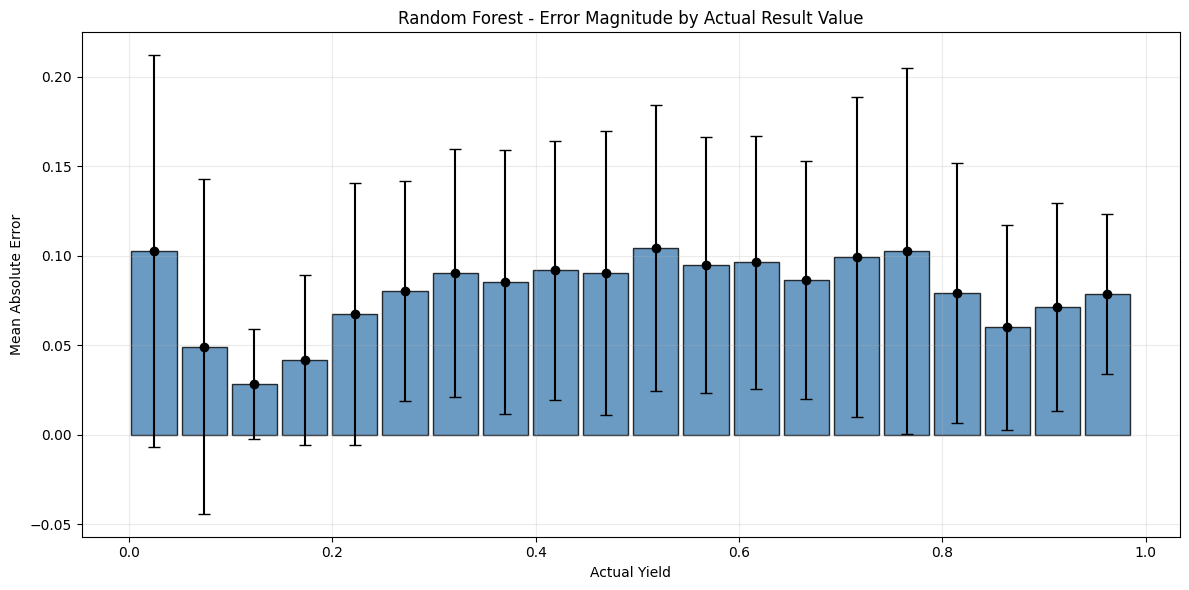

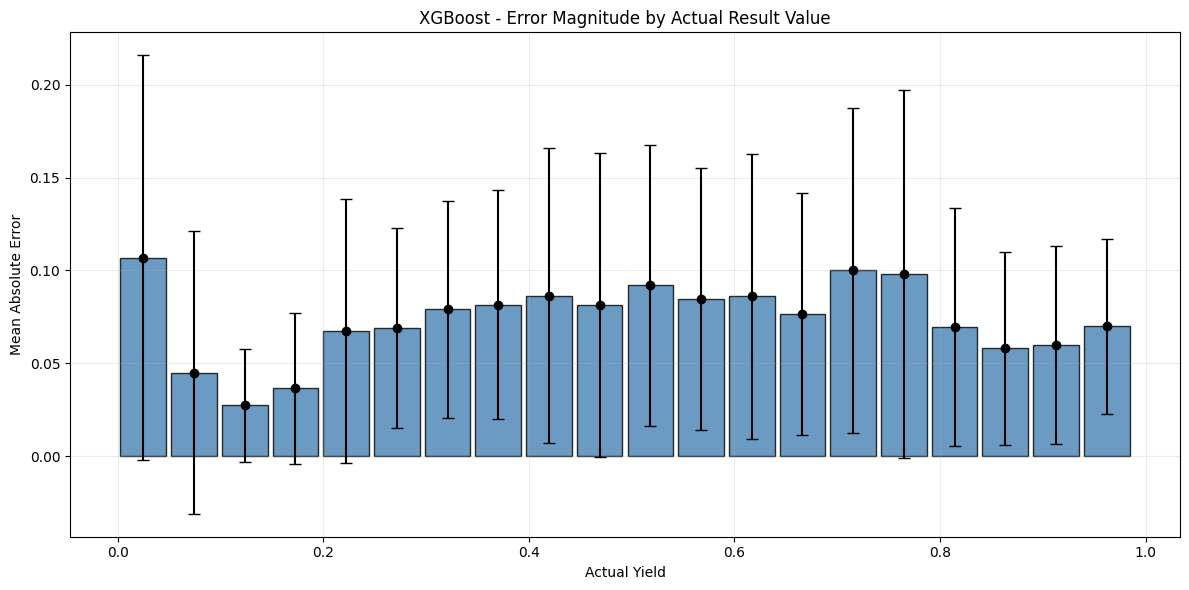

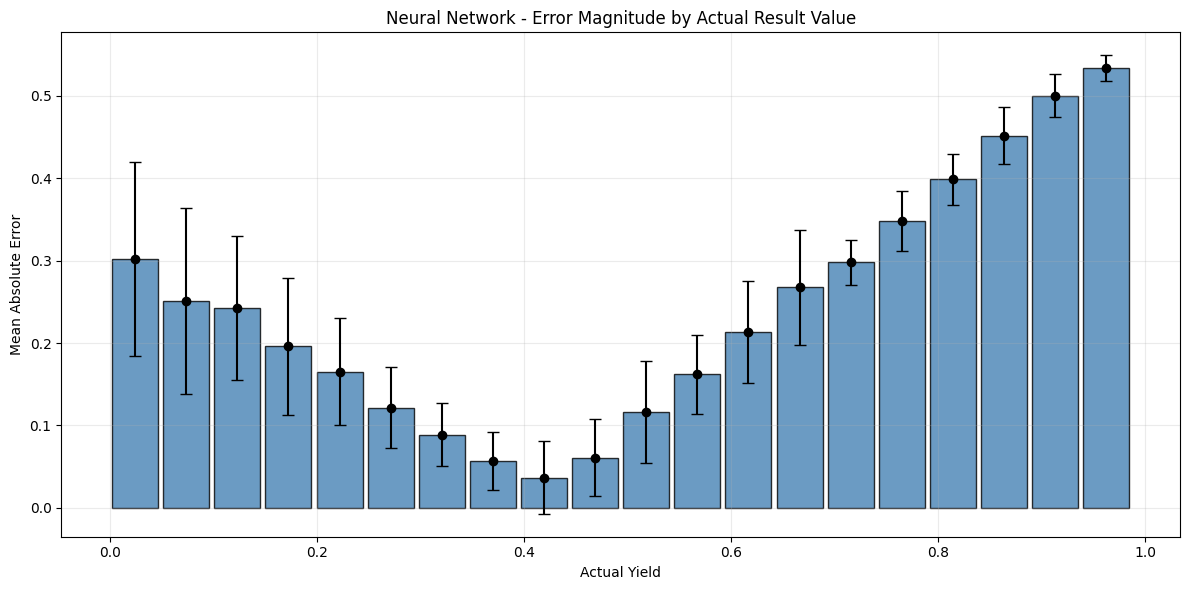

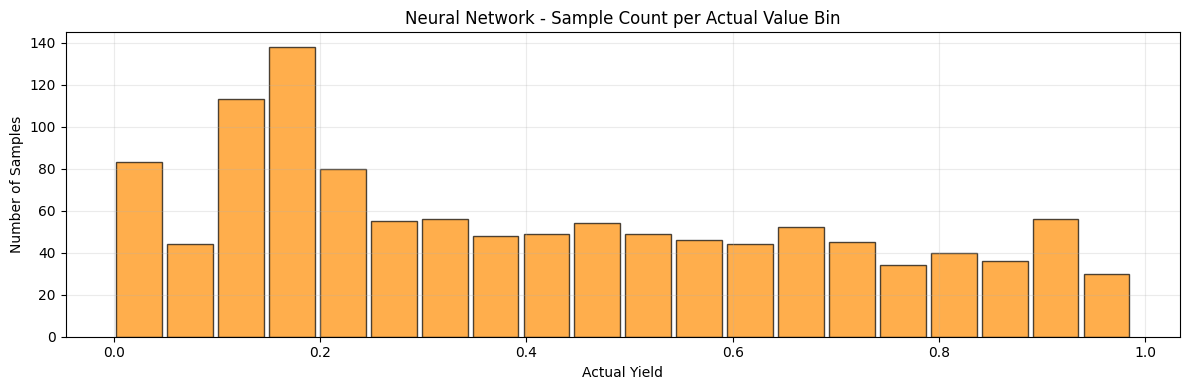

In [15]:
# Visualize error by actual value for all models
plot_error_by_actual_value(y_test, y_pred_rf, "Random Forest", n_bins=20)
plot_error_by_actual_value(y_test, y_pred_xgb, "XGBoost", n_bins=20)
plot_error_by_actual_value(y_test, y_pred_nn, "Neural Network", n_bins=20, show_sample_count=True) # Test set is the same for all models, so only show sample count for one of them

(future comment)

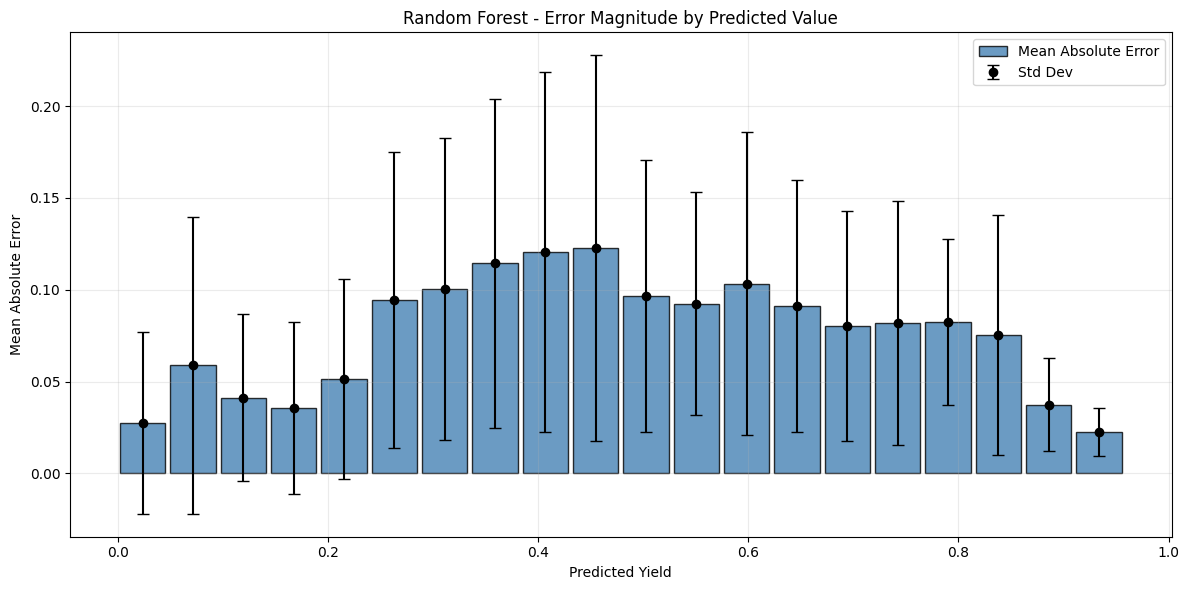

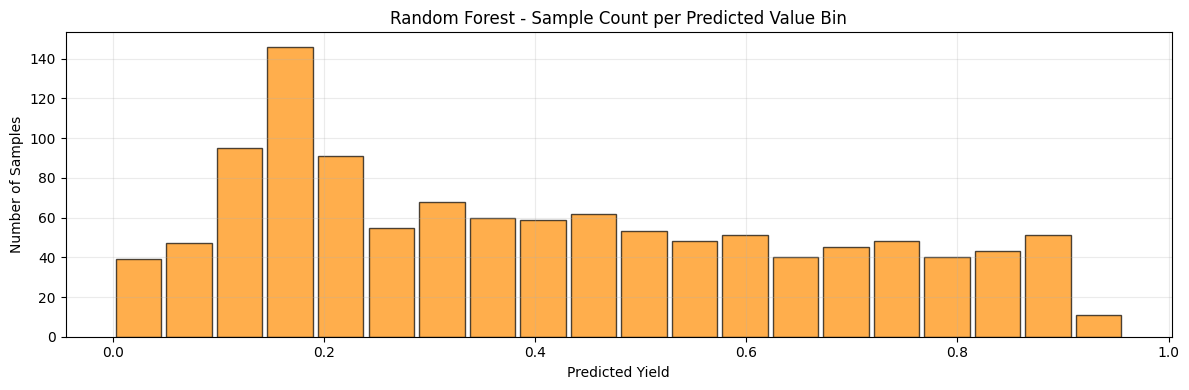

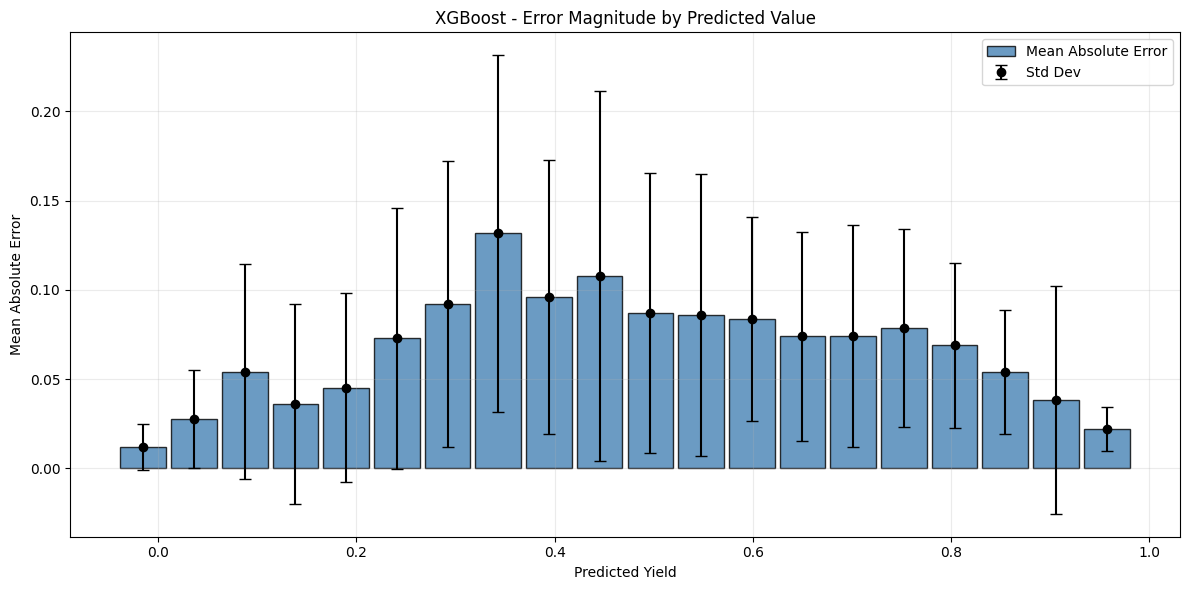

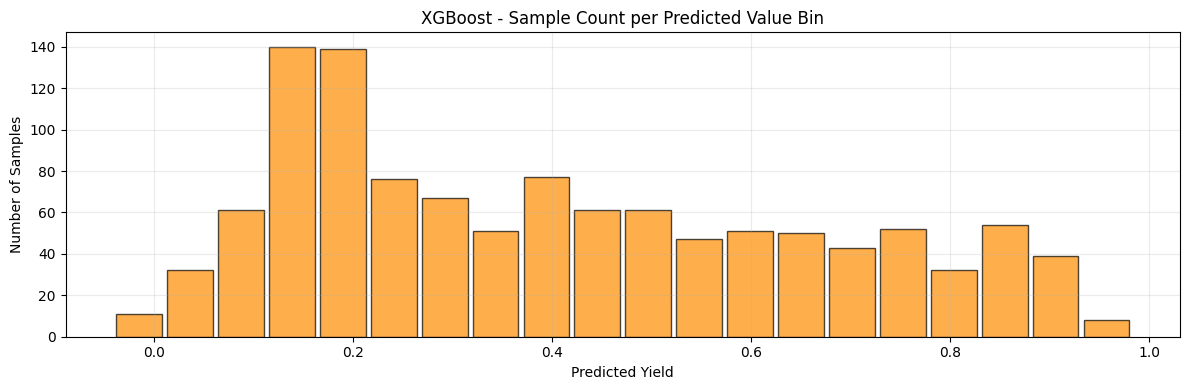

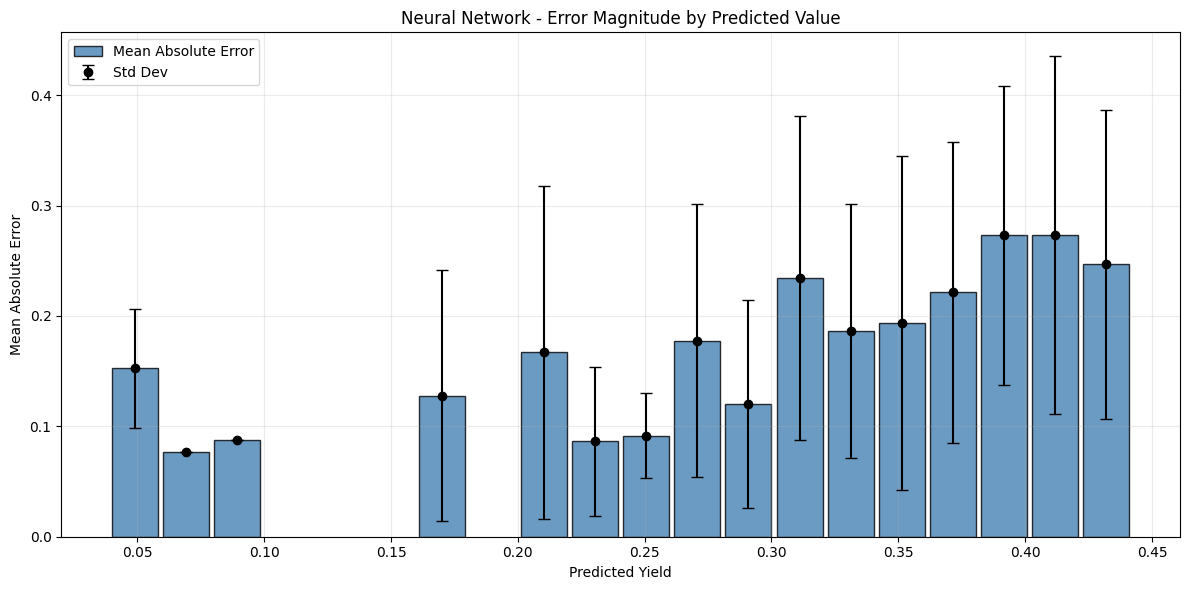

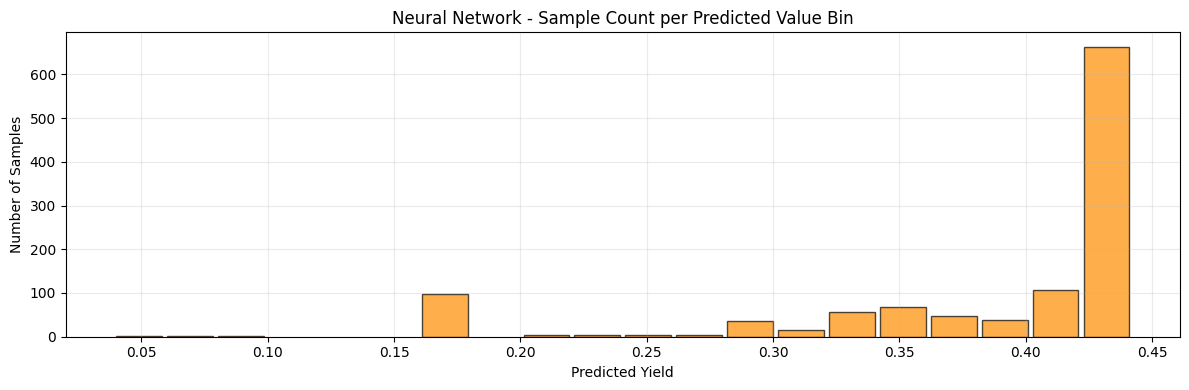

In [16]:
# Visualize error by predicted value for all models
plot_error_by_predicted_value(y_test, y_pred_rf, "Random Forest", n_bins=20, show_sample_count=True) 
plot_error_by_predicted_value(y_test, y_pred_xgb, "XGBoost", n_bins=20, show_sample_count=True)
plot_error_by_predicted_value(y_test, y_pred_nn, "Neural Network", n_bins=20, show_sample_count=True) # The predicted values will differ between models, so show sample count for all of them

(future comments)

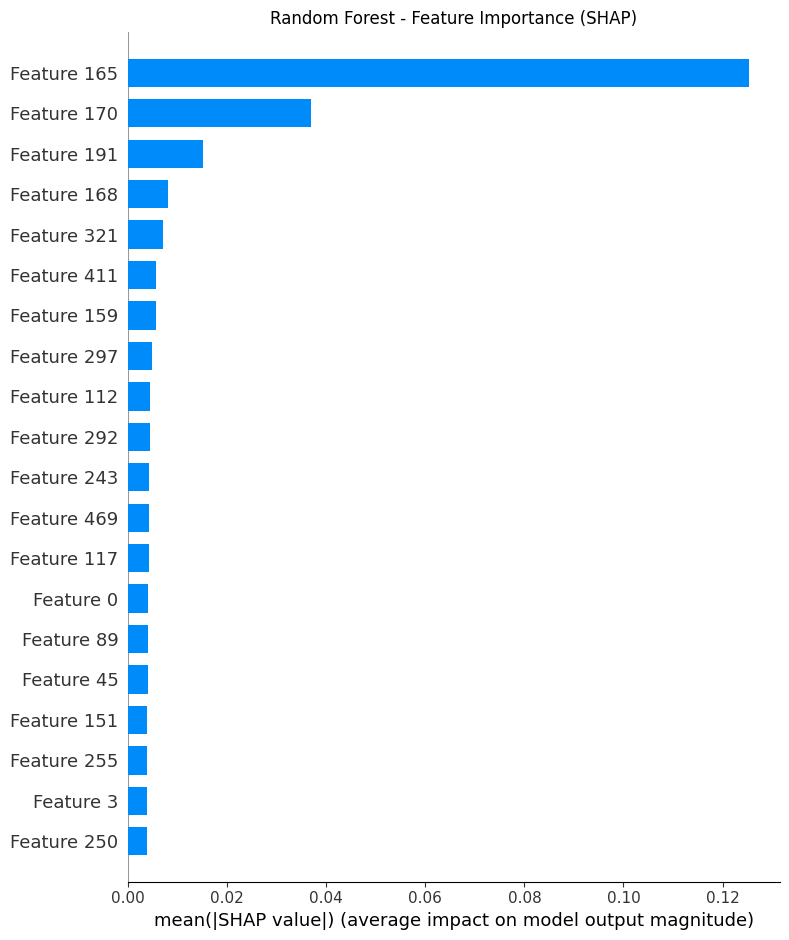

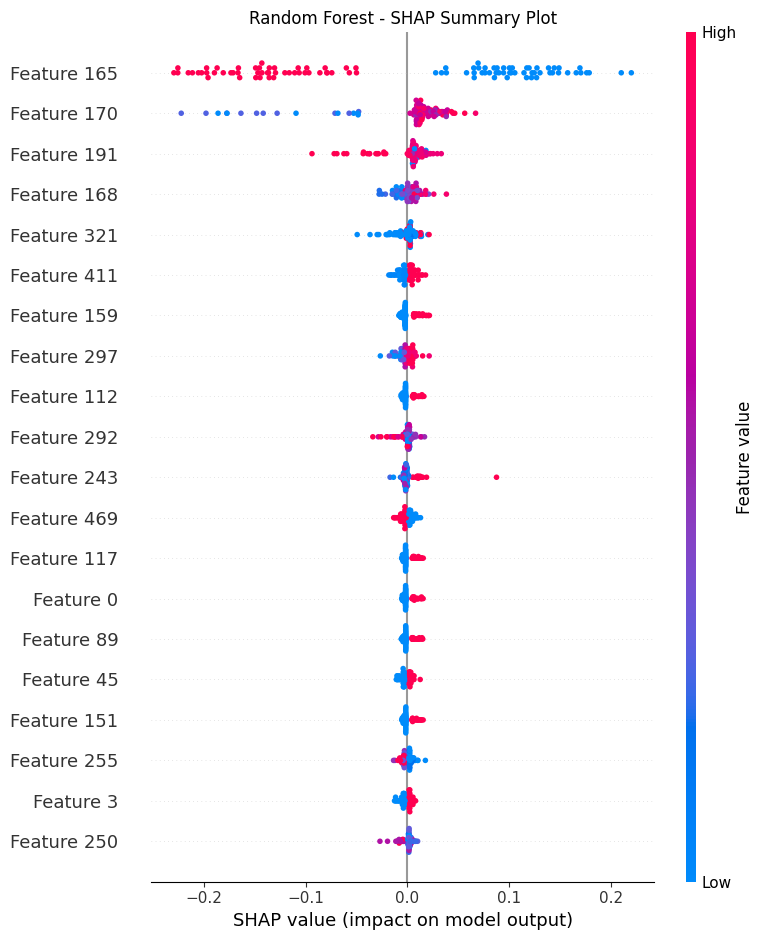

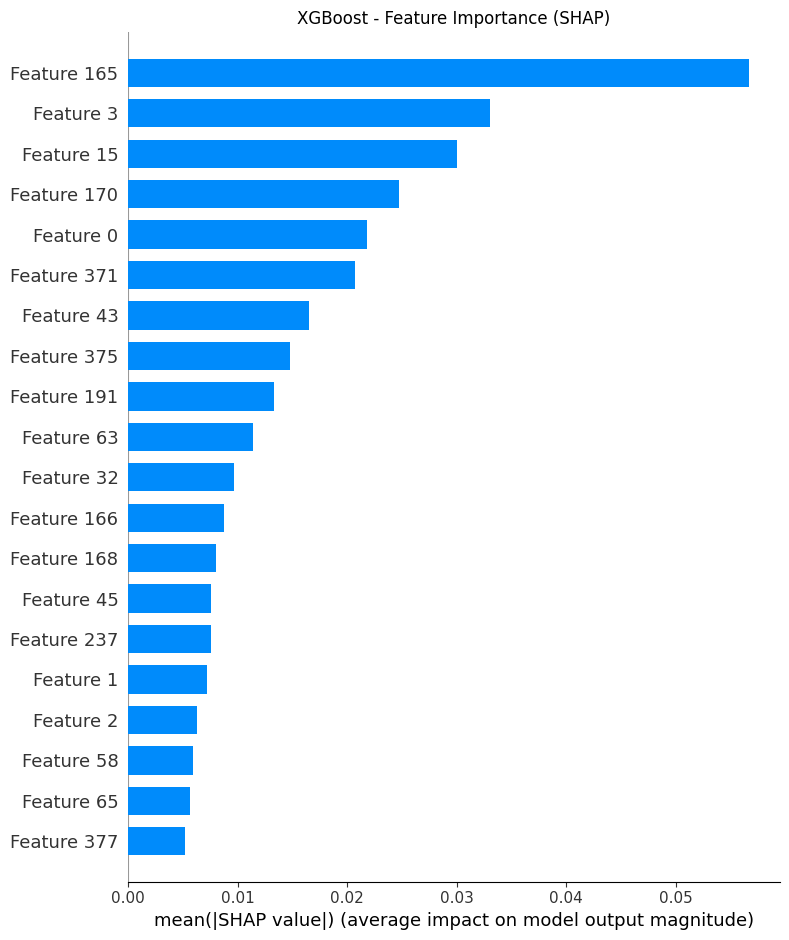

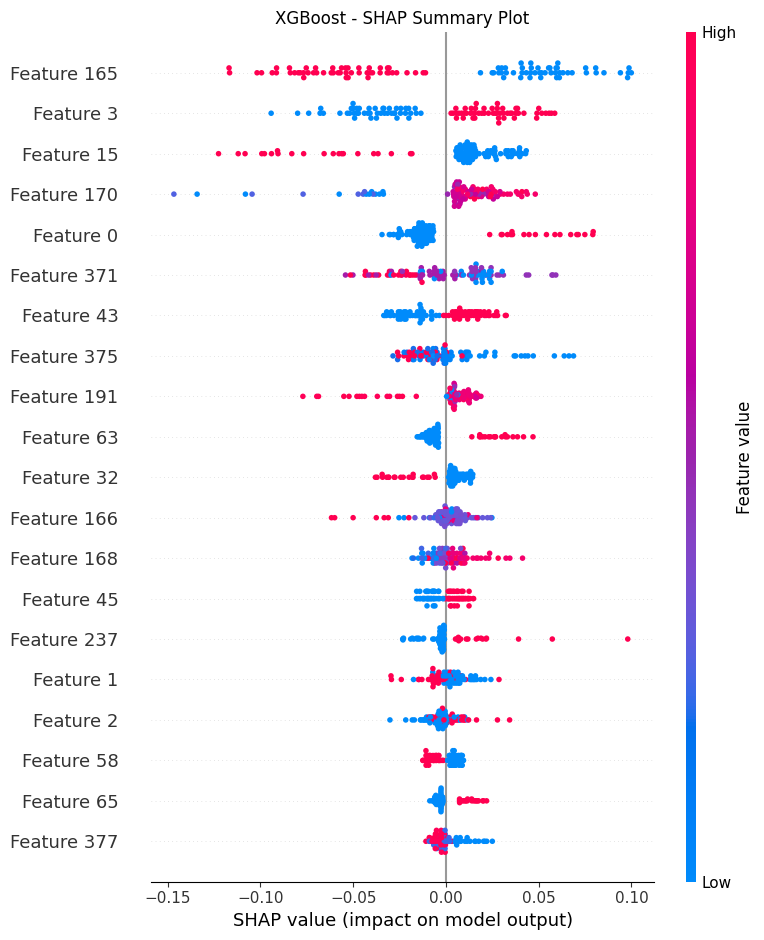

Using KernelExplainer for Neural Network (model-agnostic, slower)...


100%|██████████| 100/100 [00:47<00:00,  2.12it/s]


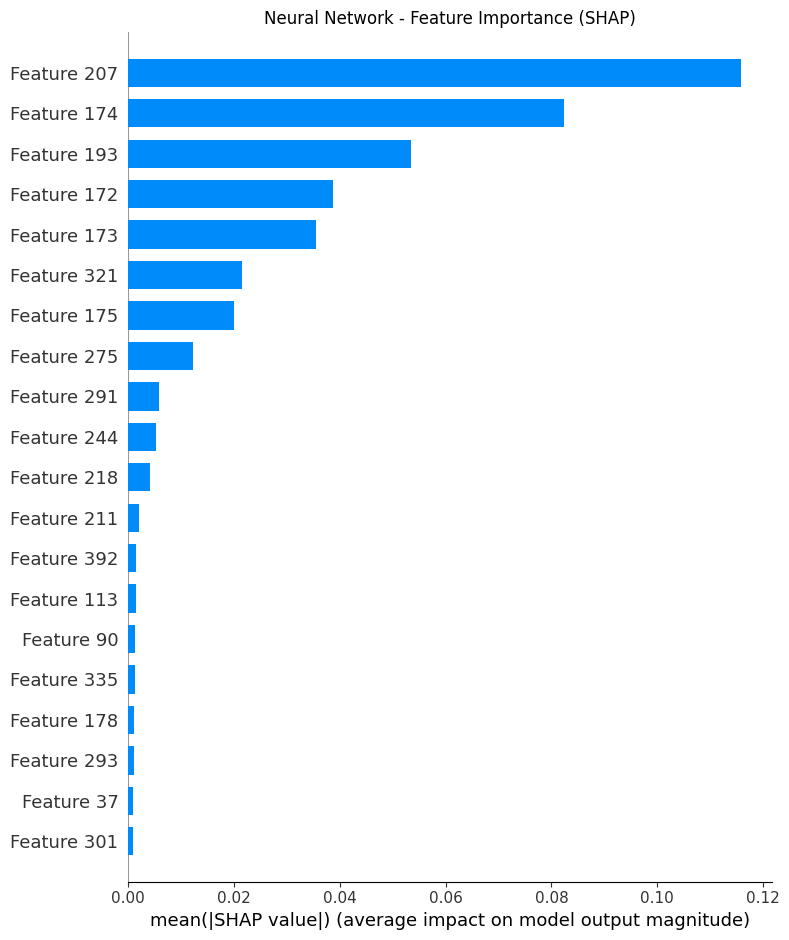

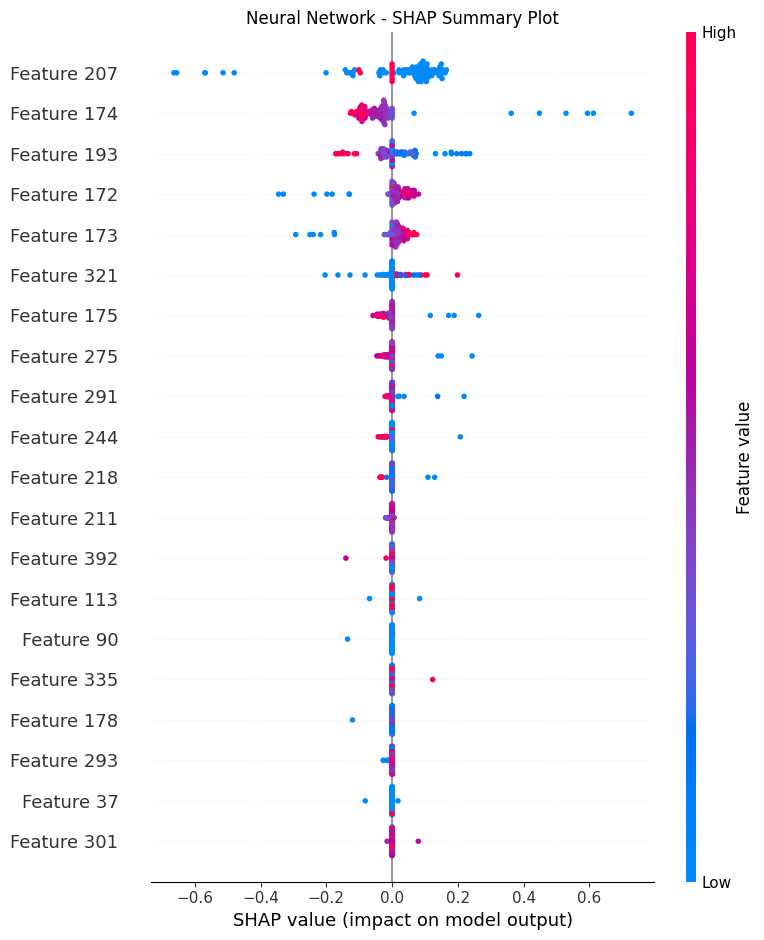

In [18]:
# Visualise SHAP feature importance for all models
explainer_rf, shap_values_rf = plot_shap_feature_importance(rf_model, x_test, "Random Forest", num_samples=100)
explainer_xgb, shap_values_xgb = plot_shap_feature_importance(xgb_model, x_test, "XGBoost", num_samples=100)
explainer_nn, shap_values_nn = plot_shap_feature_importance(nn_model, x_test, "Neural Network", num_samples=100)

(future comments)

#### **Possible error causes and improvements**

(future conclusion to error visualisation section)

### 💡 Conclusion

(Complete once the entire notebook is done)